# Chapter 11. Training Deep Neural Networks

## The Vanishing/Exploding Gradients Problems

Backpropagation computes gradients by moving backward from the output layer toward the input layer.

In deep neural networks, gradients must pass through many layers.  

As they move backward, they can become extremely small or extremely large. When gradients become too small, the lower layers receive almost no useful update and learn very slowly. This is called the vanishing gradients problem.  

When gradients become too large, the model can make unstable weight updates and diverge. This is called the exploding gradients problem.

The sigmoid activation function can make the vanishing gradients problem worse.

When the input to sigmoid is very positive or very negative, the function saturates near `1` or `0`. In these saturated regions, the curve is almost flat, so the derivative is close to `0`.

During backpropagation, gradients are computed using the chain rule. If several layers have very small activation derivatives, these small values are multiplied together, so the gradient becomes smaller as it moves toward the lower layers.

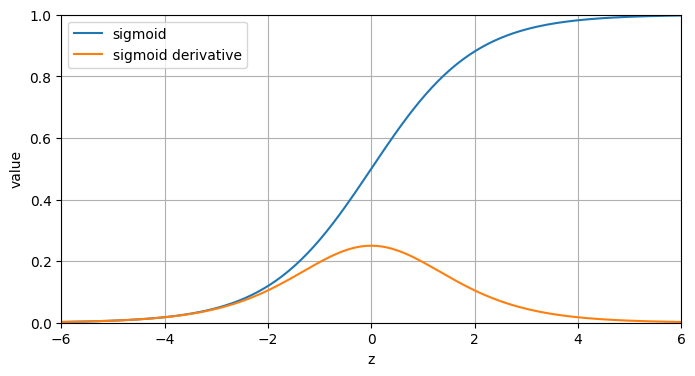

In [17]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_derivative = sigmoid * (1 - sigmoid)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, label="sigmoid")
plt.plot(z, sigmoid_derivative, label="sigmoid derivative")
plt.xlabel("z")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.axis([-6, 6, 0, 1])
plt.show()

The derivative of sigmoid is largest near `z = 0`, but it becomes very small when `z` is far from `0`.

This means that if many hidden layers use sigmoid and their activations saturate, very little gradient signal remains for the lower layers.

## Glorot Initialization and He Initialization

Weight initialization affects how signals flow through a deep neural network.

Poorly scaled initial weights can make activations and gradients shrink, grow too much, or cause activation functions to saturate. Good initialization gives the network a better starting point by keeping the scale of signals more stable during forward propagation and backpropagation.

Glorot initialization and He initialization are widely used strategies for choosing the initial scale of the weights.

The best choice depends on the activation function, but the main idea is the same: initialize weights so that signals do not vanish or explode too easily in deep networks.

In [28]:
import torch
import torch.nn as nn

layer = nn.Linear(40, 10)

nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

PyTorch layers initialize their parameters automatically, but the default initialization is not always the best match for the activation function.

For deeper networks, explicitly choosing an initialization method can make training more stable.

In [31]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model = nn.Sequential(nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1), nn.ReLU())

model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)

`model.apply()` recursively applies the initialization function to the model and its submodules.

In this example, every `nn.Linear` layer receives He initialization for its weights and zero initialization for its biases.

### Better Activation Functions

Choosing a better activation function can help reduce unstable gradients in deep neural networks.

`ReLU` became popular because it is fast and does not saturate for positive values. However, it can suffer from the dying ReLU problem: if a neuron's input stays negative for all training instances, the neuron outputs `0` and receives no useful gradient.

#### Leaky ReLU

Leaky ReLU reduces the dying ReLU problem by allowing a small negative slope when $z < 0$.

Instead of outputting exactly `0` for all negative inputs, it outputs a small negative value. This keeps some gradient flowing even when $z$ is negative.

In [39]:
alpha = 0.2

model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=alpha))

nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")

nn.init.zeros_(model[0].bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

When using `LeakyReLU`, Kaiming initialization can be adjusted for the negative slope.

`RReLU` randomly chooses the negative slope (alpha) during training and can act as a regularizer.

`PReLU` learns the negative slope (alpha) during training, but it may overfit on smaller datasets.

ReLU, Leaky ReLU, and PReLU are not smooth at $z = 0$ because their slopes change abruptly there.

This can make gradient descent bounce around more near some optima and slow down convergence.

#### ELU and SELU

ELU is linear for positive values, like ReLU, but produces negative outputs when $z < 0$.

This helps keep the average activation closer to `0`, giving the next layer a more centered input distribution. This can reduce the chance of saturation and help gradients flow more reliably through deep networks.

ELU also has a nonzero gradient when $z < 0$, which helps reduce the dead neuron problem.

However, ELU is slower to compute than ReLU because it uses an exponential function.

SELU is a scaled version of ELU.

Under specific conditions, a network using `SELU` can self-normalize, meaning that activations tend to preserve a mean close to `0` and a standard deviation close to `1`.

Self-normalization requires several conditions, including standardized inputs, LeCun normal initialization, and a plain MLP architecture.

Because these conditions are restrictive, `SELU` is useful in specific cases but is not always the default choice.

#### GELU, Swish, SwiGLU, Mish, and RELU2

`GELU`, `Swish`, and `Mish` are smooth activation functions that can work well on complex tasks.

Compared to `ReLU`, they are more computationally expensive, but their smoother shapes can sometimes help optimization.

`SwiGLU` uses a gating mechanism, where one part of the layer output controls how much information from another part should pass through.

This type of activation is commonly used in modern transformer architectures.

`RELU2` is simply squared ReLU. It keeps some advantages of `ReLU`, such as simplicity and sparse outputs, but it can be less stable because large positive values become even larger after squaring.

In practice, `ReLU` remains a strong default because it is simple, fast, and widely optimized.

For more complex tasks, `GELU`, `Swish`/`SiLU`, or `Mish` may be worth trying. If runtime speed is especially important, `ReLU` or `LeakyReLU` may be preferable.

### Batch Normalization

Batch normalization adds a normalization step inside the neural network.

For each mini-batch, it zero-centers and normalizes the inputs to the batch-normalization layer, then applies a learned scale and shift.

For each input feature, batch normalization computes the mini-batch mean and standard deviation.

Then it normalizes the input:

$$
\hat{x}^{(i)} = \frac{x^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

After normalization, it applies learned parameters $\gamma$ and $\beta$:

$$
z^{(i)} = \gamma \otimes \hat{x}^{(i)} + \beta
$$

Here, $\mu_B$ and $\sigma_B$ are computed from the current mini-batch, $\epsilon$ prevents division by zero, $\gamma$ is a learned scale parameter, and $\beta$ is a learned shift parameter.

The scale and shift parameters allow the model to choose the most useful distribution instead of forcing every normalized value to stay fixed at mean `0` and standard deviation `1`.

Batch normalization can make deep networks less sensitive to weight initialization and can reduce unstable gradients.

It can also allow larger learning rates and may act as a mild regularizer.

During training, batch normalization uses the current mini-batch statistics.

During evaluation, it uses running estimates of the mean and variance collected during training. This is why it is important to use `model.train()` during training and `model.eval()` during evaluation.

#### Implementing batch norm with PyTorch

In [64]:
model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),
    nn.Linear(1 * 28 * 28, 300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)

In this version, batch normalization is applied after flattening the input and after each hidden layer's activation.

For small networks, the improvement may be limited, but for deeper networks batch normalization can make training much more stable.

In [67]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

A batch-normalization layer has two learned parameters:

- `weight`: the scale parameter $\gamma$
- `bias`: the shift parameter $\beta$

In [69]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

It also stores buffers such as `running_mean`, `running_var`, and `num_batches_tracked`.

These are not learned by regular backpropagation, but they are updated during training and used during evaluation.

Batch normalization can also be placed before the activation function.

When batch normalization is placed before the activation, the previous `nn.Linear` layer can usually set `bias=False`, since batch normalization already includes a learned shift parameter. The first batch-normalization layer can also be removed to avoid placing the first hidden layer between two batch-normalization layers, but then the input data should be normalized before training.

In [76]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

#### Batch norm 1D, 2D, and 3D

`nn.BatchNorm1d` is used for batches shaped like `[batch_size, num_features]`.

For image tensors shaped like `[batch_size, channels, height, width]`, `nn.BatchNorm2d` is usually more appropriate because it normalizes each channel using statistics computed across the batch and spatial dimensions.

Batch normalization adds extra computation during training and inference.

However, during inference, a batch-normalization layer can often be fused with the previous linear or convolutional layer, reducing the runtime cost.

### Layer Normalization

Layer normalization is similar to batch normalization, but it normalizes across the feature dimensions instead of across the batch dimension.

This means each instance is normalized using its own features, without depending on the other instances in the mini-batch.

Unlike batch normalization, layer normalization behaves the same way during training and evaluation.

It does not need running estimates of the mean and variance because the required statistics are computed directly from each instance.

In [85]:
inputs = torch.randn(32, 3, 100, 200) # a batch of random RGB images

layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs) # normalizes over the last two dimensions

In this example, the input shape is `[batch_size, channels, height, width]`.

Using `nn.LayerNorm([100, 200])` normalizes over the last two dimensions, so each image channel is normalized separately across its height and width.

In [98]:
means = inputs.mean(dim=[2, 3], keepdim=True) # shape: [32, 3, 1, 1]
vars_ = inputs.var(dim=[2, 3], keepdim=True, unbiased=False) # shape: [32, 3, 1, 1]
stds = torch.sqrt(vars_ + layer_norm.eps)  # eps is a smoothing term (1e-5)

result = layer_norm.weight * (inputs - means) / stds + layer_norm.bias
# result shape: [32, 3, 100, 200]

The manual calculation above follows the same idea: subtract the mean, divide by the standard deviation, then apply the learned scale and shift parameters.

To normalize over the channels and spatial dimensions together, include all three dimensions in `normalized_shape`.

In [101]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs) # normalizes over the last three dimensions

Layer normalization is useful when batch statistics are unreliable, such as with small batch sizes or architectures where batch normalization is less suitable.

### Gradient Clipping

Gradient clipping is a technique for reducing the exploding gradients problem.

It limits gradients during backpropagation so that they do not exceed a chosen threshold.

In PyTorch, gradient clipping is usually applied right after `loss.backward()` and before `optimizer.step()`.

Gradient clipping is applied after `loss.backward()` and before `optimizer.step()`.

```python
for epoch in range(n_epochs):
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
```

`clip_grad_norm_()` clips gradient vectors based on their norm.

If a gradient vector is larger than `max_norm`, it is rescaled so that its norm does not exceed the threshold.

Another option is `clip_grad_value_()`, which clips each individual gradient value between `-clip_value` and `+clip_value`.

Unlike norm clipping, value clipping can change the direction of the gradient vector because each component is clipped independently.

Gradient clipping is especially useful in models where exploding gradients are common, such as recurrent neural networks.

The clipping threshold is a hyperparameter that can be tuned.